# Attack Types Analysis - CICIDS2017 (Polars Edition)

This notebook provides detailed per-attack-type analysis using **Polars** - a blazingly fast DataFrame library.

**Contents:**
1. Attack Distribution & Class Imbalance
2. Feature Distributions by Attack Type
3. Attack Signatures (Discriminative Features)
4. Multi-class Classification & Confusion Analysis
5. UMAP Visualization by Attack Type
6. Per-Attack Performance Metrics

**Polars Syntax Highlights:**
- `df.select()` instead of `df[columns]`
- `df.filter()` instead of `df[df['col'] == val]`
- `pl.col()` for column references
- `.with_columns()` to add new columns
- Method chaining is the primary pattern

In [1]:
# Install polars if needed
# !pip install polars pyarrow

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"Polars version: {pl.__version__}")
print("Libraries loaded successfully")

Polars version: 1.37.1
Libraries loaded successfully


In [3]:
# Load processed data with Polars (much faster than pandas!)
# Polars reads parquet natively
df = pl.read_parquet("../data/processed/cicids2017_clean_v2.parquet")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"\nLabel values: {df['Label'].unique().to_list()}")

Dataset shape: (2519262, 73)
Columns: 73

Label values: ['PortScan', 'DDoS', 'Web Attack - Sql Injection', 'Bot', 'Infiltration', 'DoS Slowhttptest', 'DoS GoldenEye', 'FTP-Patator', 'Web Attack - Brute Force', 'DoS Hulk', 'DoS slowloris', 'BENIGN', 'Web Attack - XSS', 'SSH-Patator', 'Heartbleed']


In [4]:
# Quick look at the data - Polars style
# .head() works the same, .glimpse() is like pandas .info()
df.head()

Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Meta_source,Has_Init_Win_fwd,Has_Init_Win_bwd
i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,i64,i64,str,str,i64,i64
54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4e6,666666.6667,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,40,0,666666.6667,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,2,12,0,0,33,0,1,20,0.0,0.0,0,0,0.0,0.0,0,0,"""BENIGN""","""Friday-WorkingHours-Afternoon-…",1,0
55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,110091.7431,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,"""BENIGN""","""Friday-WorkingHours-Afternoon-…",1,1
55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,230769.2308,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,20,20,19230.76923,19230.76923,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,"""BENIGN""","""Friday-WorkingHours-Afternoon-…",1,1
46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,352941.1765,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,20,20,29411.76471,29411.76471,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,"""BENIGN""","""Friday-WorkingHours-Afternoon-…",1,1
54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4e6,666666.6667,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,40,0,666666.6667,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,2,12,0,0,32,0,1,20,0.0,0.0,0,0,0.0,0.0,0,0,"""BENIGN""","""Friday-WorkingHours-Afternoon-…",1,0


In [5]:
# Schema inspection (column names and types)
print("Schema:")
for col, dtype in zip(df.columns[:10], df.dtypes[:10]):
    print(f"  {col}: {dtype}")
print(f"  ... and {len(df.columns) - 10} more columns")

Schema:
  Destination Port: Int64
  Flow Duration: Int64
  Total Fwd Packets: Int64
  Total Backward Packets: Int64
  Total Length of Fwd Packets: Int64
  Total Length of Bwd Packets: Int64
  Fwd Packet Length Max: Int64
  Fwd Packet Length Min: Int64
  Fwd Packet Length Mean: Float64
  Fwd Packet Length Std: Float64
  ... and 63 more columns


---
## 1. Attack Distribution & Class Imbalance

Understanding the distribution of attack types and the severity of class imbalance.

In [6]:
# Attack distribution using Polars group_by
# Note: Polars uses group_by() not groupby()
attack_counts = (
    df
    .group_by('Label')
    .agg(pl.len().alias('Count'))
    .sort('Count', descending=True)
)

# Add percentage column using with_columns
total = df.height  # Polars uses .height for row count
attack_summary = attack_counts.with_columns(
    (pl.col('Count') / total * 100).round(4).alias('Percentage'),
    (pl.col('Count').cum_sum() / total * 100).round(2).alias('Cumulative %')
)

print("Attack Type Distribution:")
print("=" * 60)
print(attack_summary)

Attack Type Distribution:
shape: (15, 4)
┌────────────────────────────┬─────────┬────────────┬──────────────┐
│ Label                      ┆ Count   ┆ Percentage ┆ Cumulative % │
│ ---                        ┆ ---     ┆ ---        ┆ ---          │
│ str                        ┆ u32     ┆ f64        ┆ f64          │
╞════════════════════════════╪═════════╪════════════╪══════════════╡
│ BENIGN                     ┆ 2094218 ┆ 83.1282    ┆ 83.13        │
│ DoS Hulk                   ┆ 172717  ┆ 6.8559     ┆ 89.98        │
│ DDoS                       ┆ 128011  ┆ 5.0813     ┆ 95.07        │
│ PortScan                   ┆ 90130   ┆ 3.5776     ┆ 98.64        │
│ DoS GoldenEye              ┆ 10286   ┆ 0.4083     ┆ 99.05        │
│ …                          ┆ …       ┆ …          ┆ …            │
│ Web Attack - Brute Force   ┆ 1470    ┆ 0.0584     ┆ 99.97        │
│ Web Attack - XSS           ┆ 652     ┆ 0.0259     ┆ 100.0        │
│ Infiltration               ┆ 36      ┆ 0.0014     ┆ 100.0   

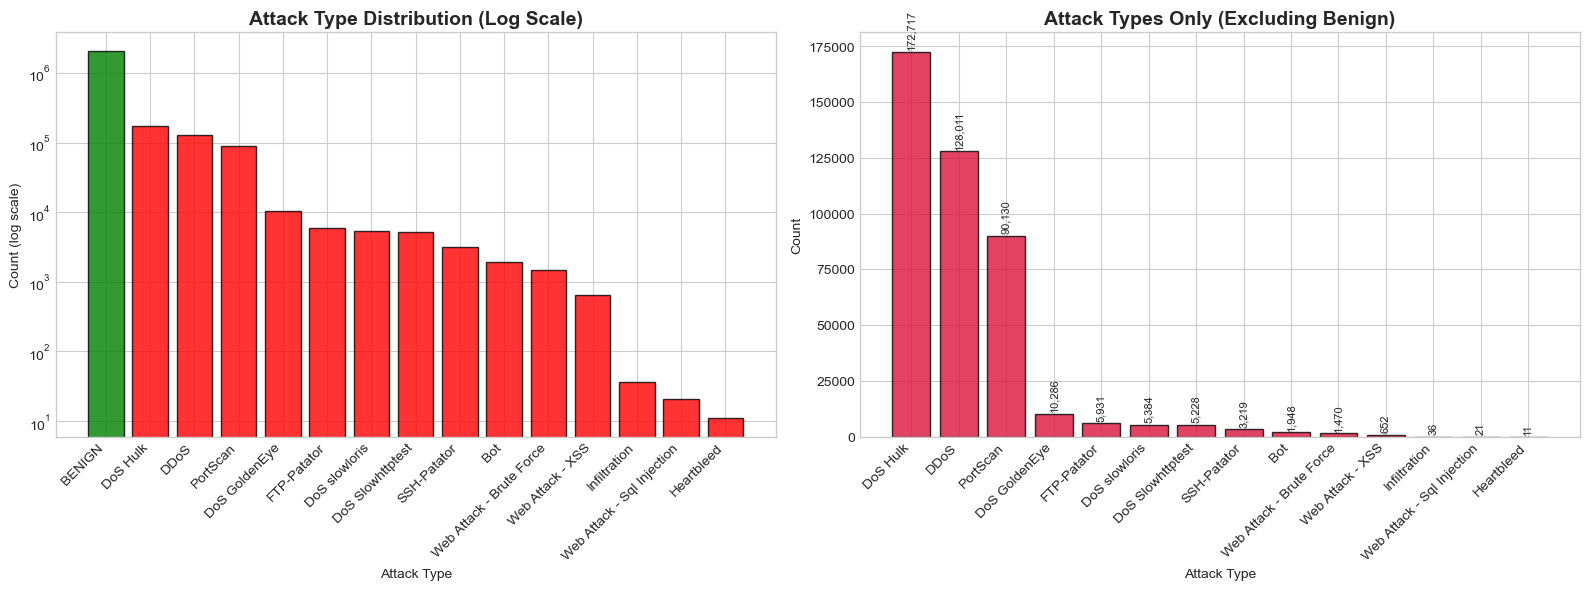


Total attacks: 425,044 (16.87%)
Total benign: 2,094,218 (83.13%)


In [7]:
# Bar chart of attack distribution
# Convert to lists for matplotlib
labels = attack_counts['Label'].to_list()
counts = attack_counts['Count'].to_list()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All attacks (log scale)
ax1 = axes[0]
colors = ['green' if label == 'BENIGN' else 'red' for label in labels]
ax1.bar(range(len(labels)), counts, color=colors, edgecolor='black', alpha=0.8)
ax1.set_yscale('log')
ax1.set_title('Attack Type Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Attack Type')
ax1.set_ylabel('Count (log scale)')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, ha='right')

# Attacks only (exclude BENIGN)
ax2 = axes[1]
attack_only = attack_counts.filter(pl.col('Label') != 'BENIGN')
attack_labels = attack_only['Label'].to_list()
attack_vals = attack_only['Count'].to_list()

ax2.bar(range(len(attack_labels)), attack_vals, color='crimson', edgecolor='black', alpha=0.8)
ax2.set_title('Attack Types Only (Excluding Benign)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Attack Type')
ax2.set_ylabel('Count')
ax2.set_xticks(range(len(attack_labels)))
ax2.set_xticklabels(attack_labels, rotation=45, ha='right')

# Add count labels
for i, v in enumerate(attack_vals):
    ax2.text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.savefig('../reports/figures/attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

total_attacks = sum(attack_vals)
benign_count = attack_counts.filter(pl.col('Label') == 'BENIGN')['Count'][0]
print(f"\nTotal attacks: {total_attacks:,} ({total_attacks/total*100:.2f}%)")
print(f"Total benign: {benign_count:,} ({benign_count/total*100:.2f}%)")

In [8]:
# Group attacks by family using Polars expressions
# Using pl.when().then().otherwise() - Polars' conditional logic
df = df.with_columns(
    pl.when(pl.col('Label') == 'BENIGN').then(pl.lit('Benign'))
    .when(pl.col('Label').str.contains('DoS|DDoS')).then(pl.lit('DoS/DDoS'))
    .when(pl.col('Label').str.contains('Patator')).then(pl.lit('Brute Force (Protocol)'))
    .when(pl.col('Label').str.contains('Web Attack')).then(pl.lit('Web Attacks'))
    .when(pl.col('Label') == 'PortScan').then(pl.lit('Reconnaissance'))
    .when(pl.col('Label') == 'Bot').then(pl.lit('Botnet'))
    .when(pl.col('Label') == 'Infiltration').then(pl.lit('Infiltration'))
    .when(pl.col('Label') == 'Heartbleed').then(pl.lit('Vulnerability Exploit'))
    .otherwise(pl.lit('Other'))
    .alias('Attack_Family')
)

# Count by family
family_counts = (
    df
    .group_by('Attack_Family')
    .agg(pl.len().alias('Count'))
    .sort('Count', descending=True)
)

print("\nAttack Family Distribution:")
print(family_counts)


Attack Family Distribution:
shape: (8, 2)
┌────────────────────────┬─────────┐
│ Attack_Family          ┆ Count   │
│ ---                    ┆ ---     │
│ str                    ┆ u32     │
╞════════════════════════╪═════════╡
│ Benign                 ┆ 2094218 │
│ DoS/DDoS               ┆ 321626  │
│ Reconnaissance         ┆ 90130   │
│ Brute Force (Protocol) ┆ 9150    │
│ Web Attacks            ┆ 2143    │
│ Botnet                 ┆ 1948    │
│ Infiltration           ┆ 36      │
│ Vulnerability Exploit  ┆ 11      │
└────────────────────────┴─────────┘


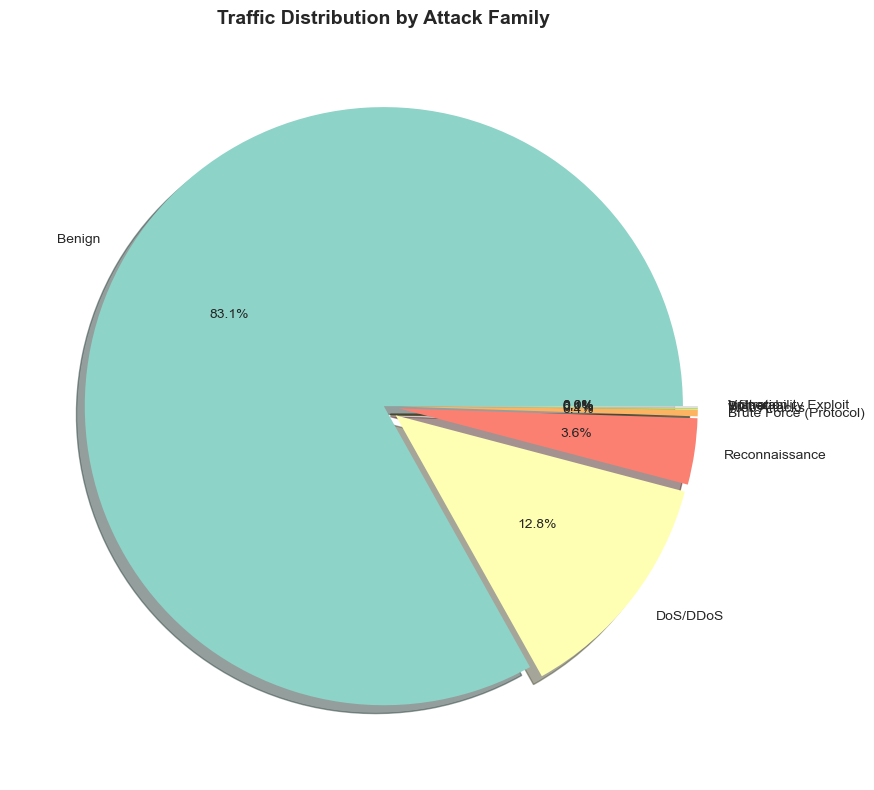

In [9]:
# Pie chart of attack families
fig, ax = plt.subplots(figsize=(10, 8))
family_labels = family_counts['Attack_Family'].to_list()
family_vals = family_counts['Count'].to_list()

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(family_labels)))
wedges, texts, autotexts = ax.pie(
    family_vals, 
    labels=family_labels,
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=[0.05 if label != 'Benign' else 0 for label in family_labels],
    shadow=True
)
ax.set_title('Traffic Distribution by Attack Family', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/attack_families_pie.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Feature Distributions by Attack Type

Analyzing how key features differ across attack types to understand attack signatures.

In [10]:
# Define key features for analysis
KEY_FEATURES = [
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Packet Length Mean',
    'Packet Length Std',
    'Flow IAT Mean',
    'SYN Flag Count',
    'FIN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'ACK Flag Count',
    'Init_Win_bytes_forward',
    'Init_Win_bytes_backward',
    'Destination Port'
]

# Verify features exist
available_features = [f for f in KEY_FEATURES if f in df.columns]
print(f"Analyzing {len(available_features)} key features")

Analyzing 18 key features


In [11]:
# Summary statistics by attack type for key features
# Polars uses .agg() with multiple expressions
feature_stats = (
    df
    .group_by('Label')
    .agg([
        pl.col(feat).mean().alias(f'{feat}_mean')
        for feat in available_features[:8]
    ] + [
        pl.col(feat).std().alias(f'{feat}_std')
        for feat in available_features[:8]
    ])
    .sort('Label')
)

print("Feature Statistics by Attack Type (first 8 features):")
print(feature_stats)

Feature Statistics by Attack Type (first 8 features):
shape: (15, 17)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Label     ┆ Flow Dura ┆ Flow Byte ┆ Flow Pack ┆ … ┆ Total     ┆ Fwd       ┆ Bwd       ┆ Packet   │
│ ---       ┆ tion_mean ┆ s/s_mean  ┆ ets/s_mea ┆   ┆ Backward  ┆ Packet    ┆ Packet    ┆ Length   │
│ str       ┆ ---       ┆ ---       ┆ n         ┆   ┆ Packets_s ┆ Length    ┆ Length    ┆ Mean_std │
│           ┆ f64       ┆ f64       ┆ ---       ┆   ┆ td        ┆ Mean_std  ┆ Mean_std  ┆ ---      │
│           ┆           ┆           ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ BENIGN    ┆ 1.2164e7  ┆ 1.6769e6  ┆ 53658.066 ┆ … ┆ 1159.5437 ┆ 212.22927 ┆ 292.65909 ┆ 192.9514 │
│           ┆        

In [12]:
# Sample data for visualization using Polars
# Demonstrates: int_range(), shuffle(), over() for per-group random ranking
# This samples UP TO 5000 rows per attack type (handles small groups like Heartbleed with 11)

max_per_group = 5000
df_sample = (
    df
    .with_columns(
        pl.int_range(pl.len()).shuffle(seed=42).over('Label').alias('_rand_rank')
    )
    .filter(pl.col('_rand_rank') < max_per_group)
    .drop('_rand_rank')
)

print(f"Sample size: {df_sample.height}")
print(f"Attack types represented: {df_sample['Label'].n_unique()}")

Sample size: 47357
Attack types represented: 15


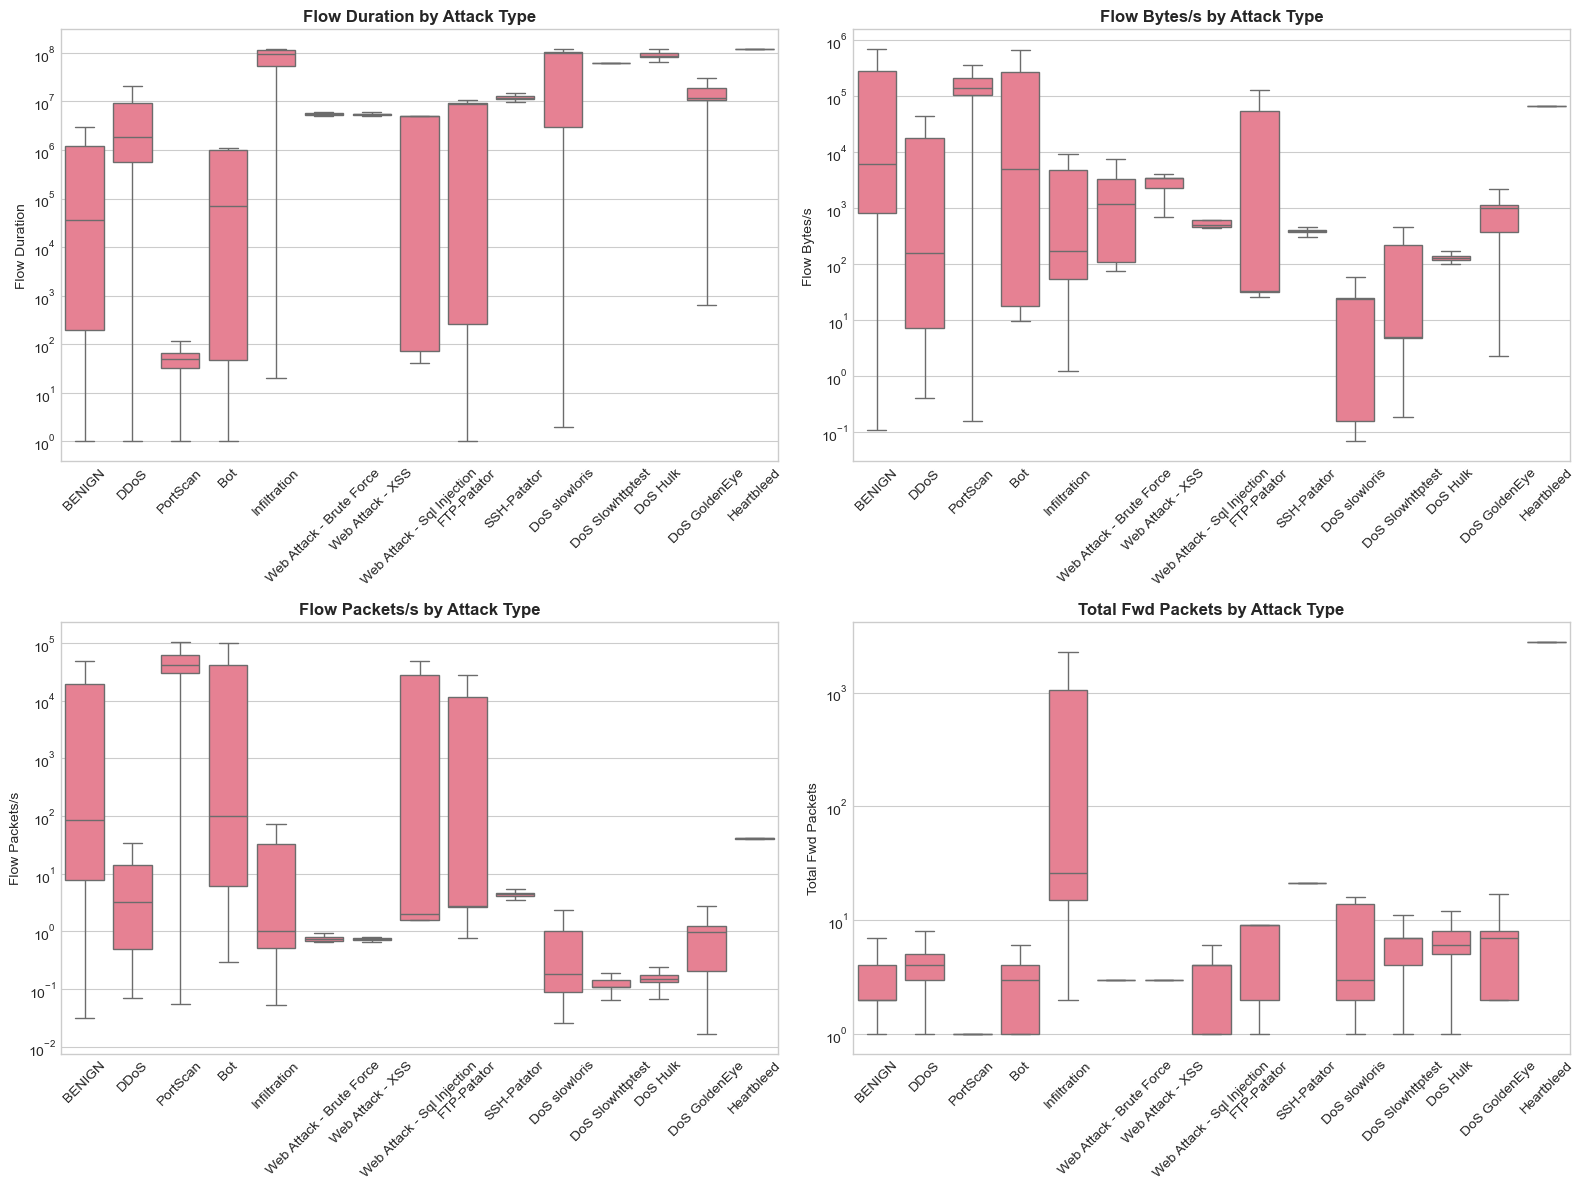

In [13]:
# Box plots for flow features - convert to pandas for seaborn
# Polars -> Pandas conversion for visualization
flow_features = ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Total Fwd Packets']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Convert sample to pandas for seaborn (seaborn needs pandas)
df_sample_pd = df_sample.to_pandas()

for idx, feature in enumerate(flow_features):
    ax = axes[idx]
    data_to_plot = df_sample_pd[df_sample_pd[feature] > 0]
    
    sns.boxplot(data=data_to_plot, x='Label', y=feature, ax=ax, showfliers=False)
    ax.set_yscale('log')
    ax.set_title(f'{feature} by Attack Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/flow_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# TCP Flag analysis by attack type using Polars
tcp_flags = ['SYN Flag Count', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count']

# Mean TCP flags per attack type
flag_means = (
    df
    .group_by('Label')
    .agg([pl.col(flag).mean().alias(flag) for flag in tcp_flags])
    .sort('Label')
)

print("\nTCP Flag Means by Attack Type:")
print(flag_means)


TCP Flag Means by Attack Type:
shape: (15, 6)
┌─────────────────┬──────────┬─────────────────┬─────────────────┬────────────────┬────────────────┐
│ Label           ┆ SYN Flag ┆ FIN Flag Count  ┆ RST Flag Count  ┆ PSH Flag Count ┆ ACK Flag Count │
│ ---             ┆ Count    ┆ ---             ┆ ---             ┆ ---            ┆ ---            │
│ str             ┆ ---      ┆ f64             ┆ f64             ┆ f64            ┆ f64            │
│                 ┆ f64      ┆                 ┆                 ┆                ┆                │
╞═════════════════╪══════════╪═════════════════╪═════════════════╪════════════════╪════════════════╡
│ BENIGN          ┆ 0.056628 ┆ 0.010478        ┆ 0.000328        ┆ 0.267693       ┆ 0.290197       │
│ Bot             ┆ 0.0      ┆ 0.0             ┆ 0.0             ┆ 0.63039        ┆ 0.36961        │
│ DDoS            ┆ 0.0      ┆ 0.000211        ┆ 0.0             ┆ 0.454531       ┆ 0.546766       │
│ DoS GoldenEye   ┆ 0.0      ┆ 0.0          

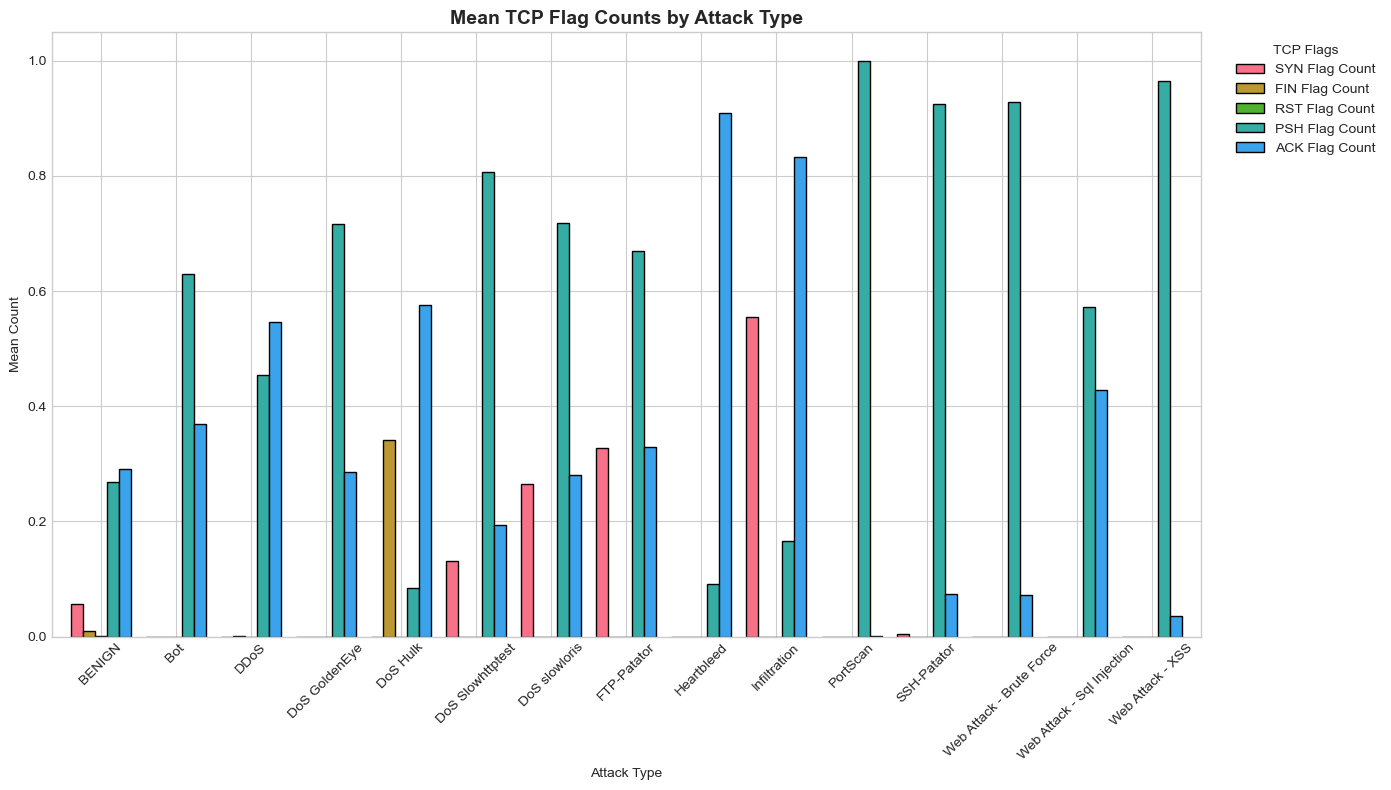

In [15]:
# Plot TCP flags
fig, ax = plt.subplots(figsize=(14, 8))

# Convert to pandas for plotting
flag_means_pd = flag_means.to_pandas().set_index('Label')
flag_means_pd.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')

ax.set_title('Mean TCP Flag Counts by Attack Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Mean Count')
ax.legend(title='TCP Flags', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/tcp_flags_by_attack.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Destination Port analysis using Polars
# Top 3 ports per attack type
port_analysis = (
    df
    .group_by(['Label', 'Destination Port'])
    .agg(pl.len().alias('Count'))
    .sort(['Label', 'Count'], descending=[False, True])
    .group_by('Label')
    .head(3)
)

print("Top 3 Destination Ports per Attack Type:")
for label in df['Label'].unique().sort().to_list():
    attack_ports = port_analysis.filter(pl.col('Label') == label)
    ports_str = ', '.join([f"{row['Destination Port']}({row['Count']:,})" 
                           for row in attack_ports.iter_rows(named=True)])
    print(f"  {label}: {ports_str}")

Top 3 Destination Ports per Attack Type:
  BENIGN: 53(876,780), 443(470,129), 80(217,791)
  Bot: 8080(1,247), 53709(1), 52343(1)
  DDoS: 80(128,008), 64869(1), 27636(1)
  DoS GoldenEye: 80(10,286)
  DoS Hulk: 80(172,717)
  DoS Slowhttptest: 80(5,228)
  DoS slowloris: 80(5,384)
  FTP-Patator: 21(5,930), 80(1)
  Heartbleed: 444(11)
  Infiltration: 444(36)
  PortScan: 80(372), 21(243), 22(243)
  SSH-Patator: 22(3,219)
  Web Attack - Brute Force: 80(1,470)
  Web Attack - Sql Injection: 80(21)
  Web Attack - XSS: 80(652)


---
## 3. Attack Signatures (Discriminative Features)

Identifying the most important features for distinguishing each attack type using Random Forest.

In [17]:
# Prepare data for feature importance analysis
exclude_cols = ['Label', 'Meta_source', 'Attack_Family']
feature_cols = [c for c in df.columns if c not in exclude_cols 
                and df[c].dtype in [pl.Float64, pl.Float32, pl.Int64, pl.Int32]]

print(f"Using {len(feature_cols)} features for importance analysis")

# Stratified sampling with minimum threshold for rare classes
# Keep ALL samples for classes with < 100 members to ensure stratified split works
min_samples_threshold = 100
sample_fraction = 0.1

df_sampled = (
    df
    .with_columns([
        pl.int_range(pl.len()).shuffle(seed=42).over('Label').alias('_rank'),
        pl.len().over('Label').alias('_class_size')
    ])
    .filter(
        # Keep all samples if class has fewer than threshold samples
        (pl.col('_class_size') < min_samples_threshold) |
        # Otherwise sample 10%
        (pl.col('_rank') < (pl.col('_class_size') * sample_fraction).cast(pl.Int64))
    )
    .drop(['_rank', '_class_size'])
)

# Extract features and labels
X = df_sampled.select(feature_cols).to_numpy()
y = df_sampled['Label'].to_numpy()

# Handle inf/nan values
X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)

print(f"Training data shape: {X.shape}")
print(f"Classes: {np.unique(y)}")
print(f"\nSamples per class:")
print(df_sampled['Label'].value_counts().sort('Label'))

Using 71 features for importance analysis
Training data shape: (251982, 71)


Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack - Brute Force' 'Web Attack - Sql Injection'
 'Web Attack - XSS']

Samples per class:
shape: (15, 2)
┌────────────────────────────┬────────┐
│ Label                      ┆ count  │
│ ---                        ┆ ---    │
│ str                        ┆ u32    │
╞════════════════════════════╪════════╡
│ BENIGN                     ┆ 209421 │
│ Bot                        ┆ 194    │
│ DDoS                       ┆ 12801  │
│ DoS GoldenEye              ┆ 1028   │
│ DoS Hulk                   ┆ 17271  │
│ …                          ┆ …      │
│ PortScan                   ┆ 9013   │
│ SSH-Patator                ┆ 321    │
│ Web Attack - Brute Force   ┆ 147    │
│ Web Attack - Sql Injection ┆ 21     │
│ Web Attack - XSS           ┆ 65     │
└────────────────────────────┴────────┘


In [18]:
# Train Random Forest for feature importance
print("Training Random Forest for feature importance...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X, y)
print("Training complete!")

# Get feature importances using Polars DataFrame
importances = pl.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort('Importance', descending=True)

print("\nTop 20 Most Important Features (Global):")
print(importances.head(20))

Training Random Forest for feature importance...


Training complete!

Top 20 Most Important Features (Global):
shape: (20, 2)
┌─────────────────────────┬────────────┐
│ Feature                 ┆ Importance │
│ ---                     ┆ ---        │
│ str                     ┆ f64        │
╞═════════════════════════╪════════════╡
│ Destination Port        ┆ 0.060322   │
│ Init_Win_bytes_backward ┆ 0.053295   │
│ Bwd Packets/s           ┆ 0.028263   │
│ Fwd Packet Length Max   ┆ 0.028054   │
│ Subflow Bwd Bytes       ┆ 0.025788   │
│ …                       ┆ …          │
│ Average Packet Size     ┆ 0.02079    │
│ Flow IAT Std            ┆ 0.020249   │
│ Packet Length Std       ┆ 0.019684   │
│ Init_Win_bytes_forward  ┆ 0.01967    │
│ Fwd IAT Mean            ┆ 0.019511   │
└─────────────────────────┴────────────┘


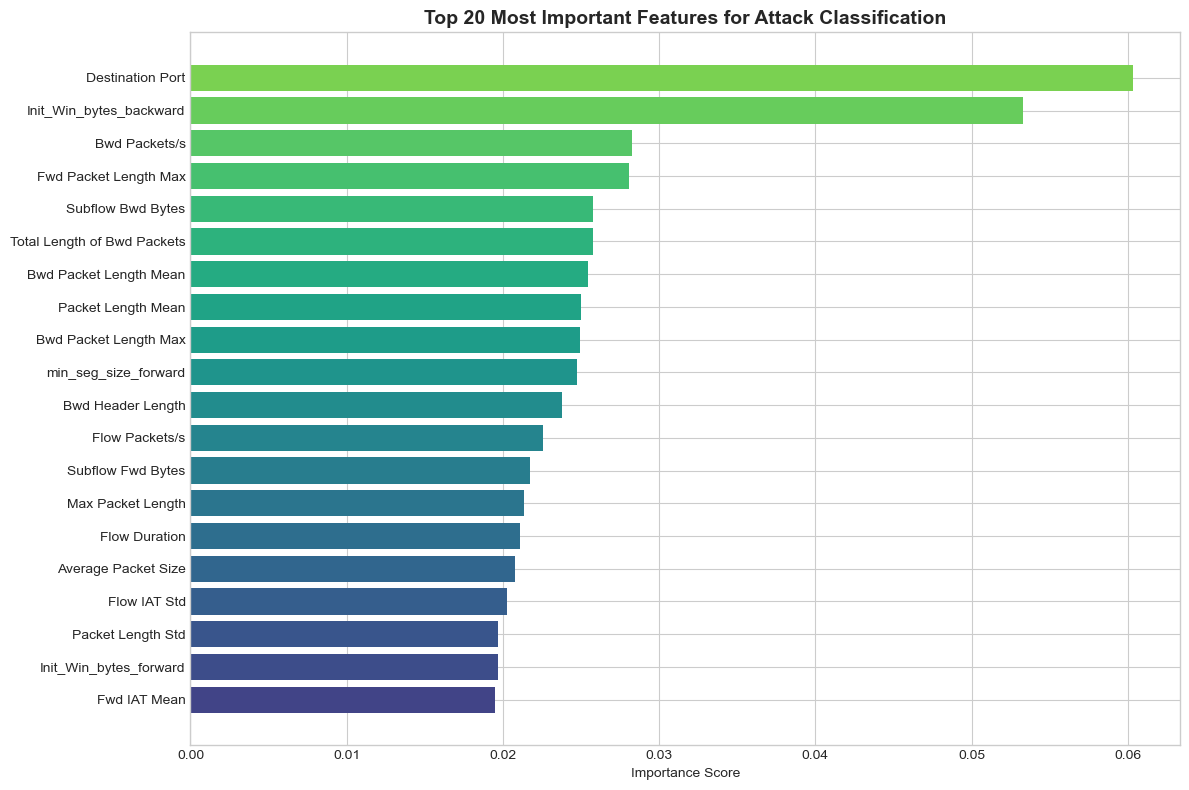

In [19]:
# Plot top 20 feature importances
fig, ax = plt.subplots(figsize=(12, 8))

top20 = importances.head(20)
features = top20['Feature'].to_list()[::-1]  # reverse for horizontal bar
values = top20['Importance'].to_list()[::-1]

ax.barh(features, values, color=plt.cm.viridis(np.linspace(0.2, 0.8, 20)))
ax.set_title('Top 20 Most Important Features for Attack Classification', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_top20.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Per-attack feature analysis using one-vs-rest importance
print("Calculating per-attack discriminative features...\n")

attack_signatures = {}
unique_attacks = [a for a in df['Label'].unique().to_list() if a != 'BENIGN']

for attack in unique_attacks:
    # Binary classification: this attack vs all others
    y_binary = (df_sampled['Label'] == attack).to_numpy().astype(int)
    
    if y_binary.sum() < 10:  # Skip if too few samples
        continue
    
    rf_binary = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    rf_binary.fit(X, y_binary)
    
    imp = pl.DataFrame({
        'Feature': feature_cols,
        'Importance': rf_binary.feature_importances_
    }).sort('Importance', descending=True)
    
    attack_signatures[attack] = imp.head(5)['Feature'].to_list()
    
    print(f"{attack}:")
    print(f"  Top 5 features: {', '.join(attack_signatures[attack])}")
    print()

Calculating per-attack discriminative features...



Infiltration:
  Top 5 features: Fwd Packet Length Mean, Avg Fwd Segment Size, Destination Port, Subflow Fwd Bytes, Total Fwd Packets



Heartbleed:
  Top 5 features: Total Fwd Packets, Bwd Header Length, Bwd Packet Length Mean, Subflow Fwd Packets, Packet Length Mean



DoS Hulk:
  Top 5 features: Bwd Packet Length Mean, Bwd Packet Length Std, Packet Length Variance, Max Packet Length, Avg Bwd Segment Size



Web Attack - Brute Force:
  Top 5 features: Init_Win_bytes_backward, Fwd IAT Min, Flow Bytes/s, Fwd Packet Length Mean, Max Packet Length



...

FTP-Patator:
  Top 5 features: Destination Port, Avg Fwd Segment Size, Average Packet Size, Fwd Packet Length Mean, Max Packet Length



PortScan:
  Top 5 features: Subflow Fwd Bytes, Packet Length Mean, Avg Fwd Segment Size, Fwd Packet Length Max, Average Packet Size



DoS GoldenEye:
  Top 5 features: Fwd Packets/s, Flow IAT Mean, Fwd IAT Total, Flow Packets/s, Fwd IAT Mean



DDoS:
  Top 5 features: Avg Fwd Segment Size, Fwd Packet Length Mean, Fwd Packet Length Max, act_data_pkt_fwd, Subflow Fwd Bytes



DoS Slowhttptest:
  Top 5 features: Flow IAT Mean, Fwd IAT Min, Fwd IAT Max, Fwd IAT Mean, Bwd Packets/s



---
## 4. Multi-class Classification & Confusion Analysis

In [21]:
# Prepare train/test split
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]:,} samples")
print(f"Test set: {X_test_scaled.shape[0]:,} samples")
print(f"Classes: {len(le.classes_)}")

Train set: 201,585 samples
Test set: 50,397 samples
Classes: 15


In [22]:
# Train multi-class Random Forest
print("Training multi-class Random Forest...")

rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_multi.fit(X_train_scaled, y_train)
y_pred = rf_multi.predict(X_test_scaled)

print("Training complete!")

Training multi-class Random Forest...


Training complete!


In [23]:
# Classification report
print("\nClassification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     41885
                       Bot       0.23      0.77      0.35        39
                      DDoS       1.00      1.00      1.00      2560
             DoS GoldenEye       0.99      0.99      0.99       206
                  DoS Hulk       1.00      1.00      1.00      3454
          DoS Slowhttptest       0.99      0.96      0.98       104
             DoS slowloris       0.99      0.98      0.99       108
               FTP-Patator       1.00      1.00      1.00       119
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      1.00      1.00      1803
               SSH-Patator       1.00      1.00      1.00        64
  Web Attack - Brute Force       0.67      0.76      0.71        29
Web Attack - Sql Inject

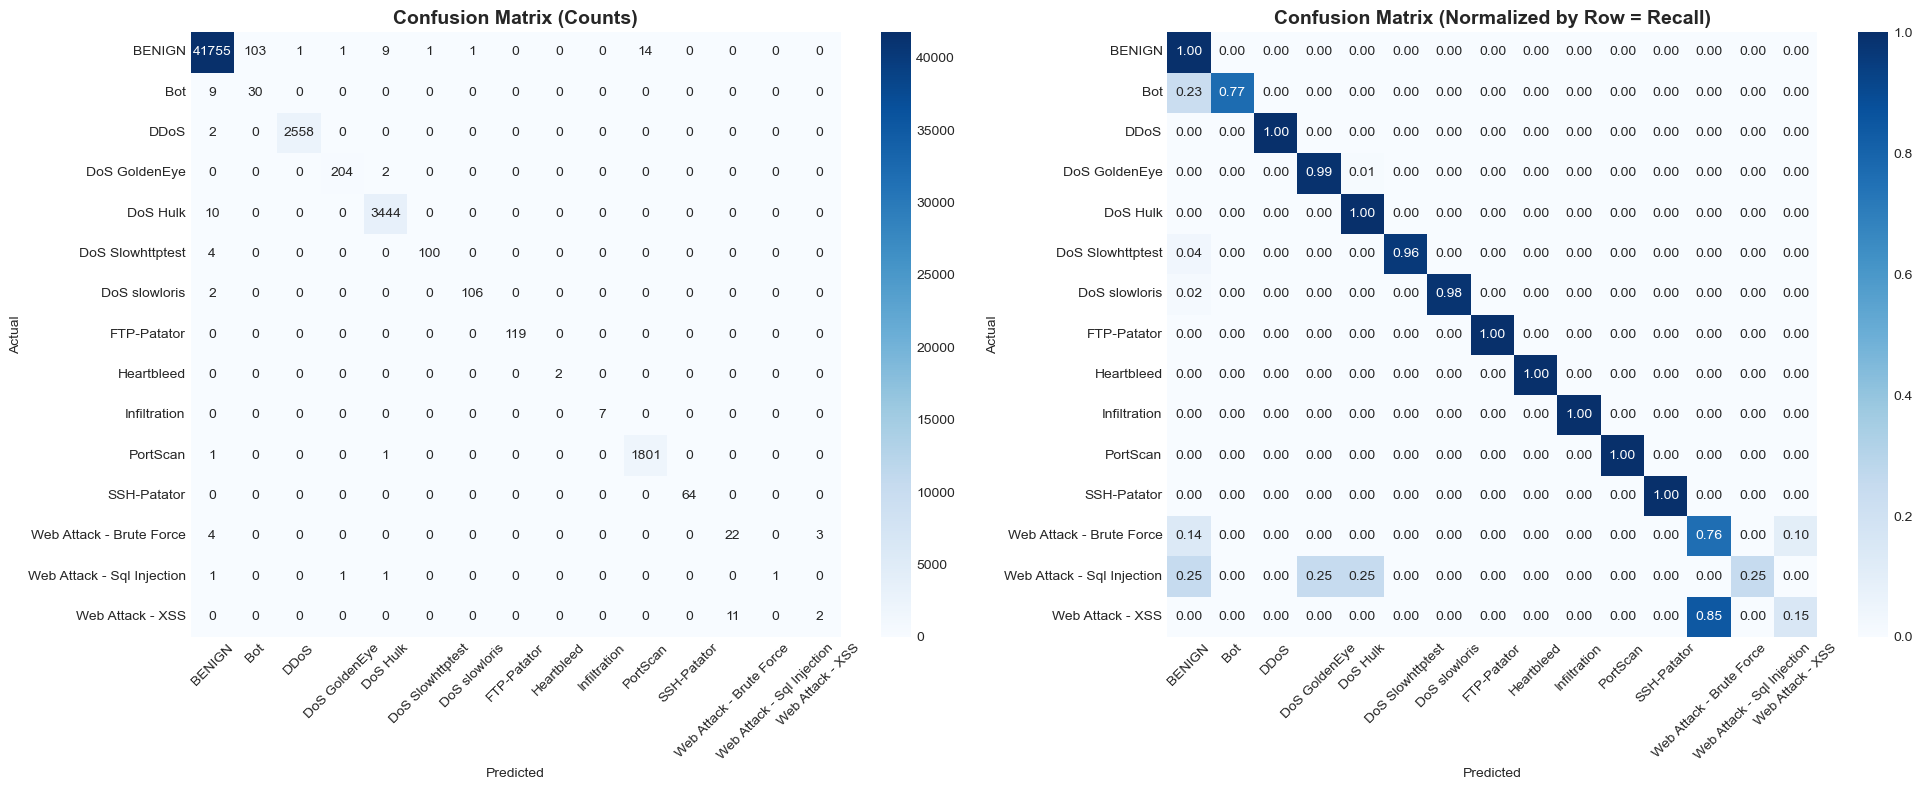

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# Normalized (recall per class)
ax2 = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('Confusion Matrix (Normalized by Row = Recall)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. UMAP Visualization by Attack Type

In [25]:
try:
    import umap
    
    # Sample balanced data for UMAP using Polars
    df_umap = df.sample(n=min(30000, df.height), seed=42)
    
    X_umap = df_umap.select(feature_cols).to_numpy()
    X_umap = np.nan_to_num(X_umap, nan=0, posinf=0, neginf=0)
    
    # Scale
    X_umap_scaled = StandardScaler().fit_transform(X_umap)
    
    print("Running UMAP dimensionality reduction...")
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_umap_scaled)
    
    # Add UMAP coordinates back to Polars DataFrame
    df_umap = df_umap.with_columns([
        pl.Series('UMAP1', embedding[:, 0]),
        pl.Series('UMAP2', embedding[:, 1])
    ])
    
    print("UMAP complete!")
    
except ImportError:
    print("UMAP not installed. Run: pip install umap-learn")
    df_umap = None

Running UMAP dimensionality reduction...


UMAP complete!


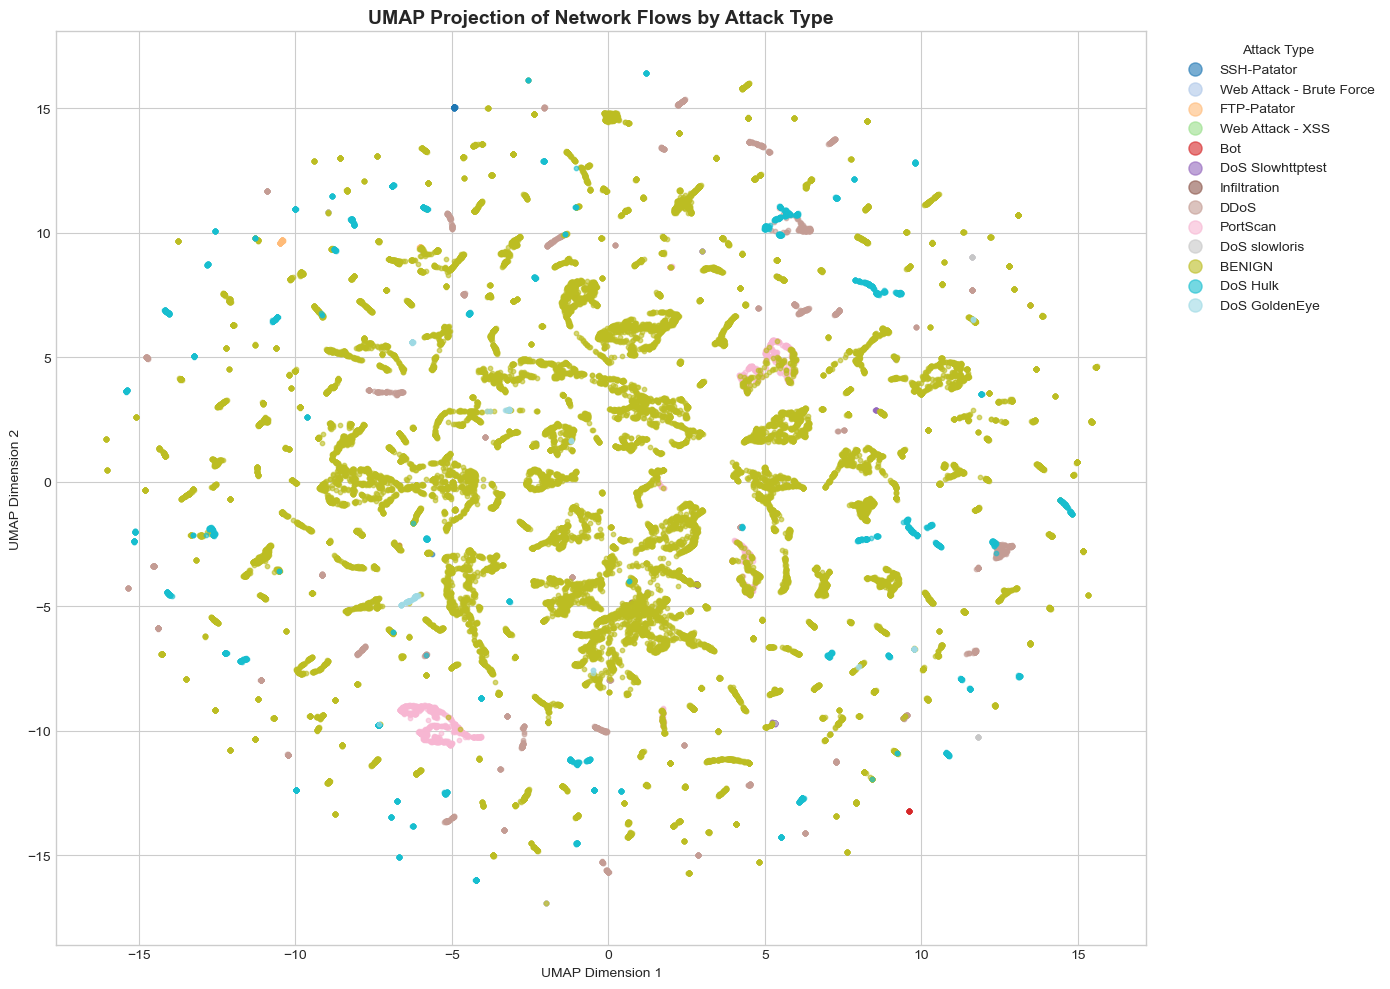

In [26]:
if df_umap is not None and 'UMAP1' in df_umap.columns:
    # Plot UMAP colored by attack type
    fig, ax = plt.subplots(figsize=(14, 10))
    
    labels = df_umap['Label'].unique().to_list()
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
    color_map = dict(zip(labels, colors))
    
    for label in labels:
        # Filter using Polars
        subset = df_umap.filter(pl.col('Label') == label)
        ax.scatter(
            subset['UMAP1'].to_numpy(),
            subset['UMAP2'].to_numpy(),
            c=[color_map[label]],
            label=label,
            alpha=0.6,
            s=10
        )
    
    ax.set_title('UMAP Projection of Network Flows by Attack Type', fontsize=14, fontweight='bold')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.legend(title='Attack Type', bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=3)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/umap_attack_types.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Per-Attack Performance Metrics Summary

In [27]:
# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(le.classes_)), zero_division=0
)

# Create results DataFrame with Polars
metrics_df = pl.DataFrame({
    'Attack Type': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support.astype(int)
}).sort('F1-Score', descending=True)

# Add detection difficulty using Polars expressions
metrics_df = metrics_df.with_columns(
    pl.when(pl.col('F1-Score') >= 0.9).then(pl.lit('Easy'))
    .when(pl.col('F1-Score') >= 0.7).then(pl.lit('Medium'))
    .otherwise(pl.lit('Hard'))
    .alias('Detection Difficulty')
)

print("\nPer-Attack Detection Performance:")
print("=" * 80)
print(metrics_df)


Per-Attack Detection Performance:
shape: (15, 6)
┌────────────────────────────┬───────────┬──────────┬──────────┬─────────┬──────────────────────┐
│ Attack Type                ┆ Precision ┆ Recall   ┆ F1-Score ┆ Support ┆ Detection Difficulty │
│ ---                        ┆ ---       ┆ ---      ┆ ---      ┆ ---     ┆ ---                  │
│ str                        ┆ f64       ┆ f64      ┆ f64      ┆ i64     ┆ str                  │
╞════════════════════════════╪═══════════╪══════════╪══════════╪═════════╪══════════════════════╡
│ FTP-Patator                ┆ 1.0       ┆ 1.0      ┆ 1.0      ┆ 119     ┆ Easy                 │
│ Heartbleed                 ┆ 1.0       ┆ 1.0      ┆ 1.0      ┆ 2       ┆ Easy                 │
│ Infiltration               ┆ 1.0       ┆ 1.0      ┆ 1.0      ┆ 7       ┆ Easy                 │
│ SSH-Patator                ┆ 1.0       ┆ 1.0      ┆ 1.0      ┆ 64      ┆ Easy                 │
│ DDoS                       ┆ 0.999609  ┆ 0.999219 ┆ 0.999414 ┆ 256

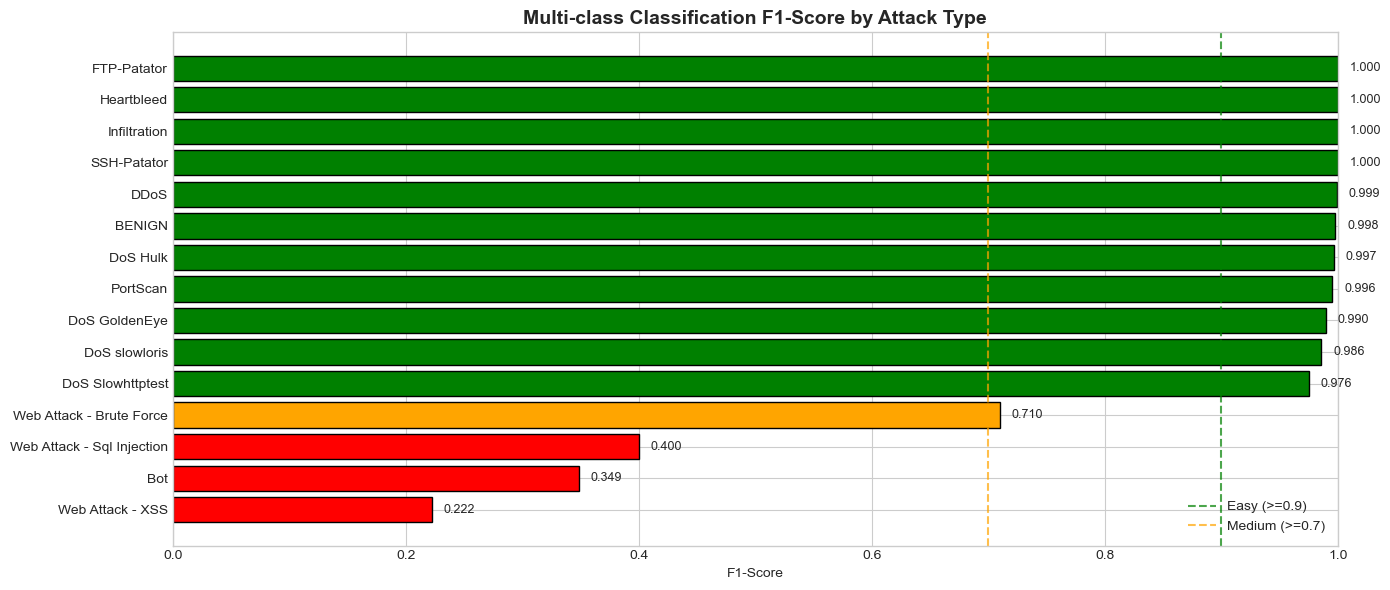

In [28]:
# Bar chart of per-attack F1 scores
fig, ax = plt.subplots(figsize=(14, 6))

metrics_sorted = metrics_df.sort('F1-Score')
attack_types = metrics_sorted['Attack Type'].to_list()
f1_scores = metrics_sorted['F1-Score'].to_list()
colors = ['green' if f1 >= 0.9 else ('orange' if f1 >= 0.7 else 'red') for f1 in f1_scores]

bars = ax.barh(attack_types, f1_scores, color=colors, edgecolor='black')
ax.axvline(x=0.9, color='green', linestyle='--', alpha=0.7, label='Easy (>=0.9)')
ax.axvline(x=0.7, color='orange', linestyle='--', alpha=0.7, label='Medium (>=0.7)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('F1-Score')
ax.set_title('Multi-class Classification F1-Score by Attack Type', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

# Add value labels
for bar, val in zip(bars, f1_scores):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/f1_score_by_attack.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary & Key Findings

In [29]:
print("KEY FINDINGS")
print("=" * 80)

# Easy to detect
easy = metrics_df.filter(pl.col('F1-Score') >= 0.9)['Attack Type'].to_list()
print(f"\n1. EASY TO DETECT (F1 >= 0.9):")
print(f"   {', '.join(easy) if easy else 'None'}")

# Medium difficulty
medium = metrics_df.filter((pl.col('F1-Score') >= 0.7) & (pl.col('F1-Score') < 0.9))['Attack Type'].to_list()
print(f"\n2. MEDIUM DIFFICULTY (0.7 <= F1 < 0.9):")
print(f"   {', '.join(medium) if medium else 'None'}")

# Hard to detect
hard = metrics_df.filter(pl.col('F1-Score') < 0.7)['Attack Type'].to_list()
print(f"\n3. HARD TO DETECT (F1 < 0.7):")
print(f"   {', '.join(hard) if hard else 'None'}")

# Top features
print(f"\n4. TOP DISCRIMINATIVE FEATURES:")
for feat in importances.head(5)['Feature'].to_list():
    print(f"   - {feat}")

KEY FINDINGS

1. EASY TO DETECT (F1 >= 0.9):
   FTP-Patator, Heartbleed, Infiltration, SSH-Patator, DDoS, BENIGN, DoS Hulk, PortScan, DoS GoldenEye, DoS slowloris, DoS Slowhttptest

2. MEDIUM DIFFICULTY (0.7 <= F1 < 0.9):
   Web Attack - Brute Force

3. HARD TO DETECT (F1 < 0.7):
   Web Attack - Sql Injection, Bot, Web Attack - XSS

4. TOP DISCRIMINATIVE FEATURES:
   - Destination Port
   - Init_Win_bytes_backward
   - Bwd Packets/s
   - Fwd Packet Length Max
   - Subflow Bwd Bytes


In [30]:
# Save artifacts using Polars
import json
import os

# Create reports directory if needed
os.makedirs('../reports/figures', exist_ok=True)

# Save feature importance - Polars write_csv
importances.write_csv('../reports/feature_importance.csv')

# Save attack signatures
with open('../reports/attack_signatures.json', 'w') as f:
    json.dump(attack_signatures, f, indent=2)

# Save metrics summary - Polars write_csv
metrics_df.write_csv('../reports/attack_metrics_summary.csv')

print("\nArtifacts saved to reports/:")
print("  - feature_importance.csv")
print("  - attack_signatures.json")
print("  - attack_metrics_summary.csv")
print("  - figures/*.png")


Artifacts saved to reports/:
  - feature_importance.csv
  - attack_signatures.json
  - attack_metrics_summary.csv
  - figures/*.png


---
## 7. Save Model Artifacts

Save the trained model, scaler, and label encoder for deployment.

In [31]:
# Save trained model and artifacts
import joblib
from datetime import datetime

# Create models directory if needed
os.makedirs('../models', exist_ok=True)

# Save model artifacts as a dictionary
model_artifacts = {
    'model': rf_multi,
    'scaler': scaler,
    'label_encoder': le,
    'feature_columns': feature_cols,
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'dataset': 'CICIDS2017',
    'model_type': 'RandomForestClassifier',
    'hyperparameters': {
        'n_estimators': 100,
        'max_depth': 20,
        'class_weight': 'balanced'
    },
    'performance': {
        'accuracy': (y_pred == y_test).mean(),
        'macro_f1': metrics_df['F1-Score'].mean(),
        'weighted_f1': ((metrics_df['F1-Score'] * metrics_df['Support']).sum() / metrics_df['Support'].sum())
    },
    'classes': le.classes_.tolist()
}

model_path = '../models/rf_multiclass_attack_classifier.joblib'
joblib.dump(model_artifacts, model_path)

print(f"Model saved to: {model_path}")
print(f"\nModel contains:")
print(f"  - RandomForestClassifier (n_estimators=100, max_depth=20)")
print(f"  - StandardScaler (fitted)")
print(f"  - LabelEncoder (15 classes)")
print(f"  - {len(feature_cols)} feature column names")
print(f"\nTo load: model_artifacts = joblib.load('{model_path}')")

Model saved to: ../models/rf_multiclass_attack_classifier.joblib

Model contains:
  - RandomForestClassifier (n_estimators=100, max_depth=20)
  - StandardScaler (fitted)
  - LabelEncoder (15 classes)
  - 71 feature column names

To load: model_artifacts = joblib.load('../models/rf_multiclass_attack_classifier.joblib')


---
## Polars Cheat Sheet

| Pandas | Polars |
|--------|--------|
| `df['col']` | `df['col']` or `df.select('col')` |
| `df[['a', 'b']]` | `df.select(['a', 'b'])` |
| `df[df['col'] > 5]` | `df.filter(pl.col('col') > 5)` |
| `df['new'] = val` | `df.with_columns(pl.lit(val).alias('new'))` |
| `df.groupby('col').agg()` | `df.group_by('col').agg()` |
| `df.shape[0]` | `df.height` |
| `df.shape[1]` | `df.width` |
| `df.values` | `df.to_numpy()` |
| `df.to_csv()` | `df.write_csv()` |
| `pd.read_parquet()` | `pl.read_parquet()` |
| `df.apply(func)` | `df.with_columns(pl.col('x').map_elements(func))` |
| `np.where(cond, a, b)` | `pl.when(cond).then(a).otherwise(b)` |